In [ ]:
pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.3 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🔥 Final Accuracy: 0.9475

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.86      0.87        36
           1       0.94      0.95      0.95       160
           2       0.85      0.94      0.89        18
           3       0.97      0.96      0.97       186

    accuracy                           0.95       400
   macro avg       0.91      0.93      0.92       400
weighted avg       0.95      0.95      0.95       400



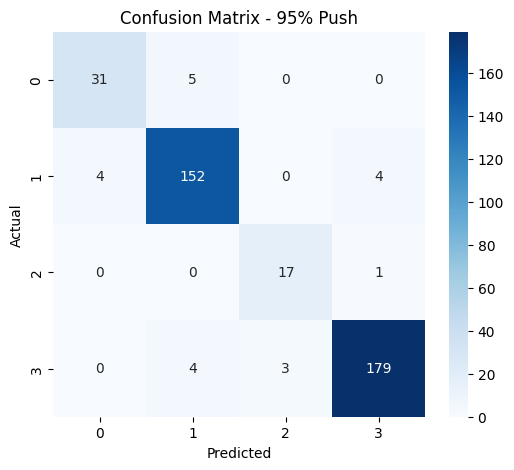

In [ ]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, PolynomialFeatures
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("ITQMS_Dataset.csv")
df.drop(["Record_ID", "Faculty_ID"], axis=1, inplace=True)

le = LabelEncoder()
df["Teaching_Quality_Label"] = le.fit_transform(df["Teaching_Quality_Label"])

X = df.drop("Teaching_Quality_Label", axis=1)
y = df["Teaching_Quality_Label"]



X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)



poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)



selector = SelectKBest(mutual_info_classif, k=int(X_train.shape[1]*0.6))
X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)



smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)



xgb = XGBClassifier(
    n_estimators=1500,
    learning_rate=0.015,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.1,
    reg_alpha=0.5,
    reg_lambda=1,
    eval_metric='mlogloss',
    random_state=42
)

lgbm = LGBMClassifier(
    n_estimators=1500,
    learning_rate=0.015,
    num_leaves=80,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

cat = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.015,
    depth=8,
    verbose=0,
    random_state=42
)



stack = StackingClassifier(
    estimators=[
        ('xgb', xgb),
        ('lgbm', lgbm),
        ('cat', cat)
    ],
    final_estimator=LogisticRegression(max_iter=3000),
    cv=StratifiedKFold(n_splits=10),
    passthrough=True,
    n_jobs=-1
)


stack.fit(X_train, y_train)



y_pred = stack.predict(X_test)

print(" Final Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True,
            fmt='d',
            cmap='Blues')
plt.title("Confusion Matrix - 95% Push")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


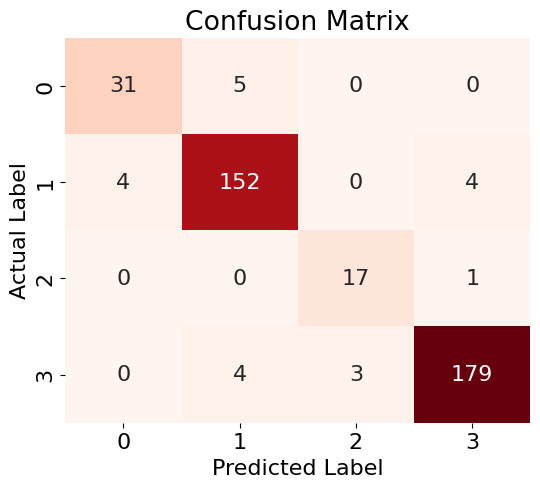

In [ ]:


import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Reds',
            cbar=False)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.grid(False)
plt.show()


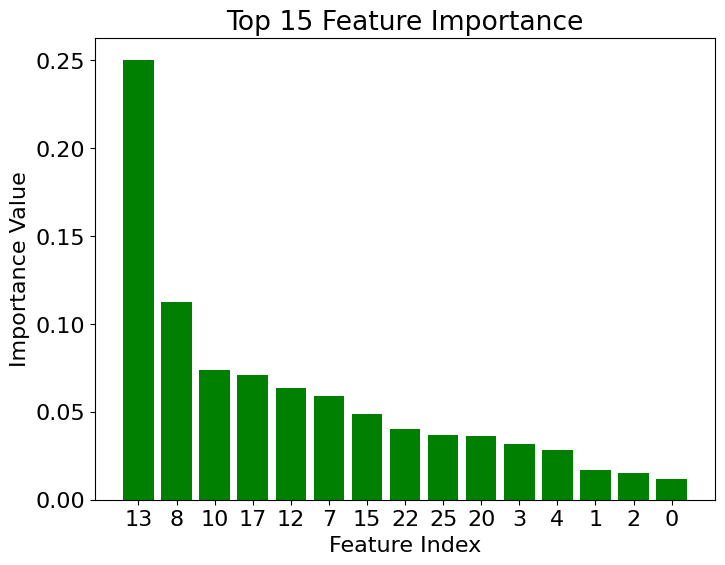

In [ ]:


import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16


trained_xgb = stack.named_estimators_['xgb']

importances = trained_xgb.feature_importances_
indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(8,6))
plt.bar(range(len(indices)),
        importances[indices],
        color="green")

plt.title("Top 15 Feature Importance")
plt.xlabel("Feature Index")
plt.ylabel("Importance Value")
plt.xticks(range(len(indices)), indices)
plt.grid(False)
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


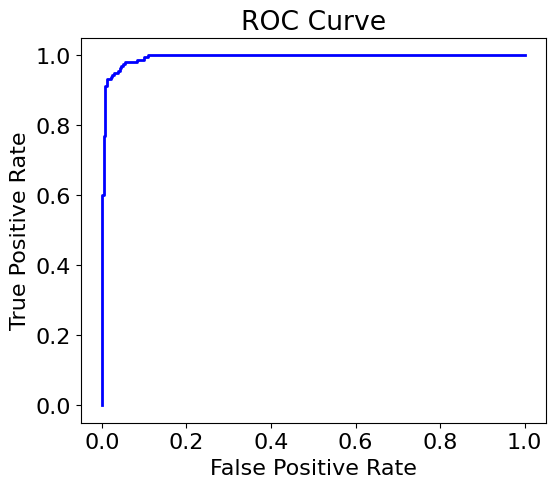

In [ ]:


from sklearn.metrics import roc_curve, auc

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16

y_prob = stack.predict_proba(X_test)
fpr, tpr, _ = roc_curve(y_test, y_prob[:,1], pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="blue", linewidth=2)

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(False)
plt.show()


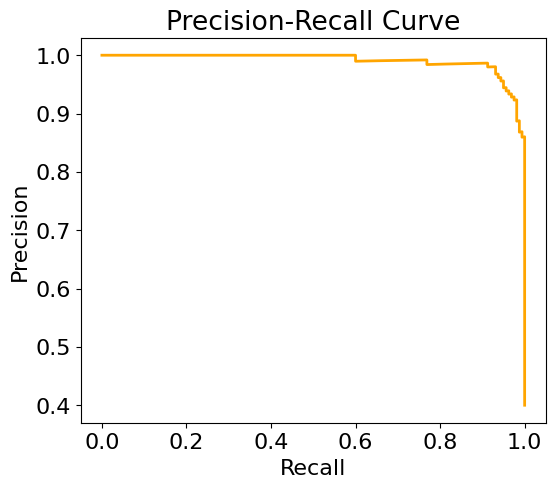

In [ ]:

from sklearn.metrics import precision_recall_curve

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16

precision, recall, _ = precision_recall_curve(y_test, y_prob[:,1], pos_label=1)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, color="orange", linewidth=2)

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(False)
plt.show()


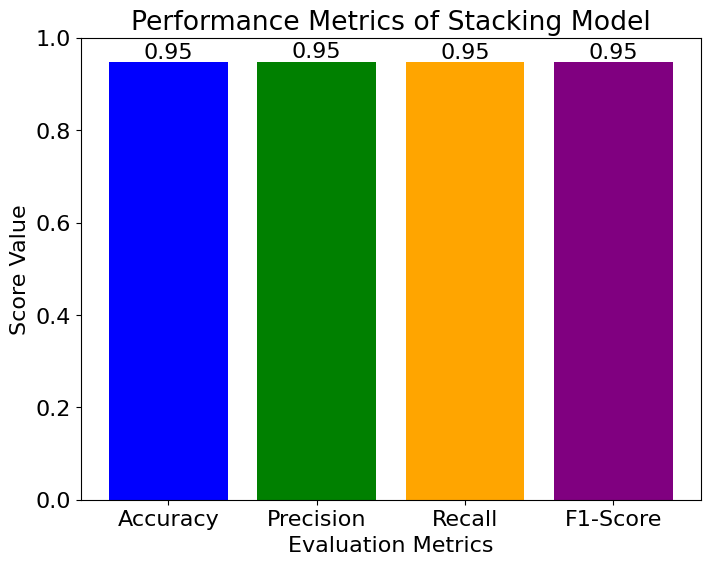

In [ ]:


import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(8,6))
bars = plt.bar(metrics, values,
               color=["blue", "green", "orange", "purple"])


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{height:.2f}",
             ha='center',
             va='bottom')

plt.title("Performance Metrics of Stacking Model")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score Value")
plt.ylim(0, 1)
plt.grid(False)
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


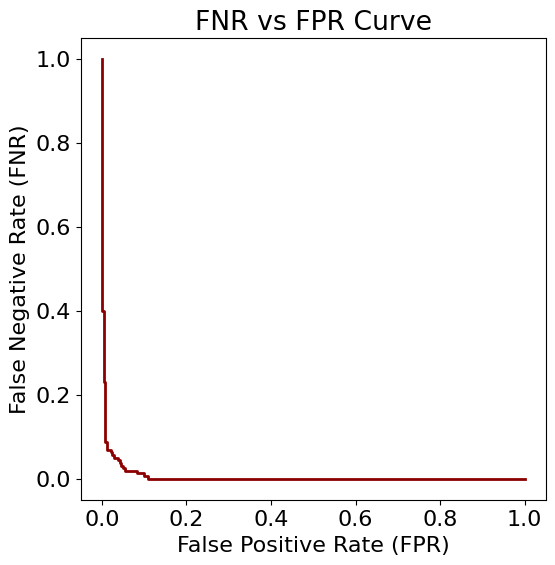

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, confusion_matrix

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16


y_prob = stack.predict_proba(X_test)


fpr, tpr, thresholds = roc_curve(y_test, y_prob[:, 1], pos_label=1)


fnr = 1 - tpr

plt.figure(figsize=(6,6))
plt.plot(fpr, fnr, color="darkred", linewidth=2)

plt.title("FNR vs FPR Curve")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("False Negative Rate (FNR)")
plt.grid(False)
plt.show()


In [ ]:

import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16

train_sizes, train_scores, val_scores = learning_curve(
    stack,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, color="blue", linewidth=2, label="Training Accuracy")
plt.plot(train_sizes, val_mean, color="green", linewidth=2, label="Validation Accuracy")

plt.title("Accuracy Learning Curve")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(False)
plt.show()
